# Загрузка данных

In [ ]:
# from google.colab import userdata
# import json
# import os

# KAGGLE_JSON_PATH = os.path.expanduser("~/.config/kaggle/kaggle.json")

# kaggle_dir = os.path.dirname(KAGGLE_JSON_PATH)
# os.makedirs(kaggle_dir, exist_ok=True)

# kaggle_json = json.loads(userdata.get("kaggle_json"))

# with open(KAGGLE_JSON_PATH, "w") as f:
#     json.dump(kaggle_json, f)

# !chmod 600 ~/.config/kaggle/kaggle.json

# !kaggle competitions download -c stars-classification
# !unzip /content/stars-classification.zip

# Анализ датасета

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
import re

plt.style.use("ggplot")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

df = pd.read_csv("/content/train_star.csv")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20732 entries, 0 to 20731
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Vmag         20732 non-null  float64
 1   Plx          20732 non-null  float64
 2   e_Plx        20732 non-null  float64
 3   B-V          20732 non-null  float64
 4   SpType       20732 non-null  object 
 5   Amag         20732 non-null  float64
 6   TargetClass  20732 non-null  object 
dtypes: float64(5), object(2)
memory usage: 1.1+ MB


In [ ]:
df.isna().sum()

,0
Vmag,0
Plx,0
e_Plx,0
B-V,0
SpType,0
Amag,0
TargetClass,0


In [ ]:
print(f"Total objects: {len(df)}")

print(f"Total missing values: {df.isna().iloc[:,0].sum()}")

print()

print(f"Number of   numerical columns: {df.dtypes[df.dtypes != "object"].value_counts().sum()}")
print(f"Number of categorical columns: {df.dtypes[df.dtypes == "object"].value_counts().sum()}")

Total objects: 20732
Total missing values: 0

Number of   numerical columns: 5
Number of categorical columns: 2


In [ ]:
def parse_sptype_simple(sptype_series: pd.Series) -> pd.DataFrame:
    # Словари
    spec_map = {
        "O": 0,
        "B": 1,
        "A": 2,
        "F": 3,
        "G": 4,
        "K": 5,
        "M": 6,
        "C": 7,
    }
    lum_map = {'I': 1, 'II': 2, 'III': 3, 'IV': 4, 'V': 5}

    def extract(row):
        s = str(row).strip()
        if not s or s == 'nan':
            return pd.Series([np.nan, np.nan])

        s_clean = re.sub(r'[^A-Za-z0-9/.]', '', s)

        spec_letter = None
        for char in s_clean:
            if char in spec_map:
                spec_letter = char
                break

        spec_num = spec_map.get(spec_letter, np.nan)

        lum_num = np.nan
        for roman, num in [('III', 3), ('II', 2), ('IV', 4), ('VI', np.nan), ('I', 1), ('V', 5)]:
            if roman in s:
                if roman == 'VI':
                    continue
                lum_num = num
                break

        return pd.Series([spec_num, lum_num])

    result = sptype_series.apply(extract)
    result.columns = ['spectral_class_num', 'luminosity_class_num']
    return result

sptype_parse = parse_sptype_simple(df["SpType"])

df_with_sptype_parsed = pd.concat([sptype_parse, df], axis=1)
df_with_sptype_parsed

,spectral_class_num,luminosity_class_num,Vmag,Plx,e_Plx,B-V,SpType,Amag,TargetClass
0,4.0,5.0,9.99,7.92,1.61,0.646,G5/G6V,19.483625,Giant
1,6.0,5.0,10.86,3.26,2.12,1.840,M1V:,18.426088,Giant
2,3.0,5.0,8.83,7.57,1.05,0.461,F3V,18.225480,Giant
3,4.0,4.0,7.72,24.80,0.89,0.613,G3IV,19.692257,Giant
4,4.0,3.0,8.81,3.17,1.03,0.872,G6III,16.315296,Dwarf
...,...,...,...,...,...,...,...,...,...
20727,3.0,5.0,7.07,14.88,0.90,0.586,F8V,17.933014,Giant
20728,3.0,5.0,9.11,4.71,0.87,0.485,F5V,17.475105,Giant
20729,2.0,4.0,9.69,1.61,1.56,0.384,A2/A3IV,15.724129,Giant
20730,5.0,5.0,8.06,37.33,0.97,0.758,K1V,20.920290,Giant


In [ ]:
df = df_with_sptype_parsed.drop("SpType", axis=1)

In [ ]:
df.head(10)

,spectral_class_num,luminosity_class_num,Vmag,Plx,e_Plx,B-V,Amag,TargetClass
0,4.0,5.0,9.99,7.92,1.61,0.646,19.483625,Giant
1,6.0,5.0,10.86,3.26,2.12,1.840,18.426088,Giant
2,3.0,5.0,8.83,7.57,1.05,0.461,18.225480,Giant
3,4.0,4.0,7.72,24.80,0.89,0.613,19.692257,Giant
4,4.0,3.0,8.81,3.17,1.03,0.872,16.315296,Dwarf
5,6.0,3.0,7.11,3.65,0.87,1.528,14.921465,Dwarf
6,1.0,4.0,8.60,2.06,0.89,0.031,15.169336,Giant
7,3.0,5.0,8.86,1.26,1.65,0.522,14.361853,Giant
8,4.0,4.0,9.45,9.77,1.51,0.689,19.399473,Giant
9,4.0,5.0,9.56,5.64,2.42,0.679,18.316395,Giant


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
spectral_class_num,20731.0,3.214124,1.388022,0.00,2.000000,3.000000,4.000000,7.000000
luminosity_class_num,20732.0,4.265242,0.947323,1.00,3.000000,5.000000,5.000000,5.000000
Vmag,20732.0,8.045100,1.299999,-0.01,7.370000,8.280000,8.930000,12.560000
Plx,20732.0,8.774717,15.186434,-27.84,3.020000,5.680000,10.170000,772.330000
e_Plx,20732.0,1.157515,0.888745,0.42,0.820000,1.010000,1.280000,40.630000
B-V,20732.0,0.584712,0.457422,-0.40,0.227000,0.526000,0.923000,3.315000
Amag,20732.0,16.671187,2.407249,-0.35,15.284584,16.706049,18.282476,30.449015


In [ ]:
df.loc[df["TargetClass"] == "Dwarf", "TargetClass"] = 0
df.loc[df["TargetClass"] == "Giant", "TargetClass"] = 1

df["TargetClass"] = df["TargetClass"].astype("int8")

In [ ]:
# sns.pairplot(df, hue="TargetClass")

In [ ]:
def print_outliers(df: pd.DataFrame):
    def get_num_outliers(column: pd.Series) -> int:
        q1 = np.percentile(column, 25)
        q3 = np.percentile(column, 75)
        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        return ((column < lower) | (column > upper)).sum()

    print("Number of outliers for each column:")

    max_col_width = max(len(col) for col in df.columns)

    for column in df.columns:
        print(f"{column:<{max_col_width}}: {get_num_outliers(df[column])}")

print_outliers(df)

Number of outliers for each column:
spectral_class_num  : 0
luminosity_class_num: 0
Vmag                : 592
Plx                 : 1574
e_Plx               : 1078
B-V                 : 33
Amag                : 472
TargetClass         : 4939


In [ ]:
q1 = df["e_Plx"].quantile(0.25)
q3 = df["e_Plx"].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outlier_idx = df[(df["e_Plx"] < lower) | (df["e_Plx"] > upper)].index

df.drop(outlier_idx, axis=0, inplace=True)

In [ ]:
df_train = df
X, y = df_train.iloc[:, :-1], df_train.iloc[:, -1]
X

,spectral_class_num,luminosity_class_num,Vmag,Plx,e_Plx,B-V,Amag
0,4.0,5.0,9.99,7.92,1.61,0.646,19.483625
2,3.0,5.0,8.83,7.57,1.05,0.461,18.225480
3,4.0,4.0,7.72,24.80,0.89,0.613,19.692257
4,4.0,3.0,8.81,3.17,1.03,0.872,16.315296
5,6.0,3.0,7.11,3.65,0.87,1.528,14.921465
...,...,...,...,...,...,...,...
20727,3.0,5.0,7.07,14.88,0.90,0.586,17.933014
20728,3.0,5.0,9.11,4.71,0.87,0.485,17.475105
20729,2.0,4.0,9.69,1.61,1.56,0.384,15.724129
20730,5.0,5.0,8.06,37.33,0.97,0.758,20.920290


<Axes: xlabel='TargetClass', ylabel='count'>

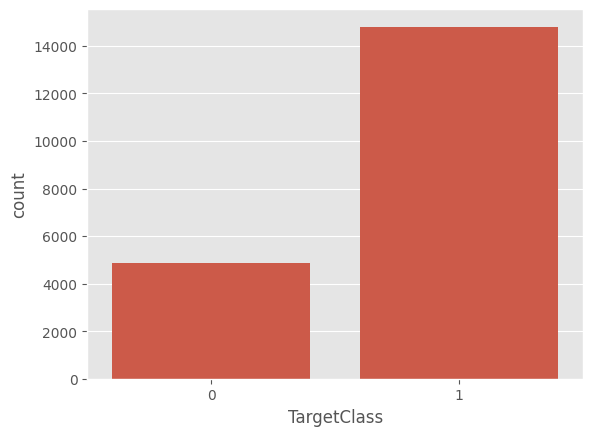

In [ ]:
sns.countplot(df, x="TargetClass")

In [ ]:
rows_with_nan = df_train[df_train.isna().any(axis=1)]

df_train = df_train.drop(rows_with_nan.index)

In [ ]:
df_train

,spectral_class_num,luminosity_class_num,Vmag,Plx,e_Plx,B-V,Amag,TargetClass
0,4.0,5.0,9.99,7.92,1.61,0.646,19.483625,1
2,3.0,5.0,8.83,7.57,1.05,0.461,18.225480,1
3,4.0,4.0,7.72,24.80,0.89,0.613,19.692257,1
4,4.0,3.0,8.81,3.17,1.03,0.872,16.315296,0
5,6.0,3.0,7.11,3.65,0.87,1.528,14.921465,0
...,...,...,...,...,...,...,...,...
20727,3.0,5.0,7.07,14.88,0.90,0.586,17.933014,1
20728,3.0,5.0,9.11,4.71,0.87,0.485,17.475105,1
20729,2.0,4.0,9.69,1.61,1.56,0.384,15.724129,1
20730,5.0,5.0,8.06,37.33,0.97,0.758,20.920290,1


In [ ]:
X, y = df_train.iloc[:, :-1], df_train.iloc[:, -1]

# Baseline

In [ ]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, random_state=42, test_size=0.2, shuffle=True)
# X_train, y_train = X, y

model = LogisticRegression()

model.fit(X_train, y_train)
print("Качество модели: ", model.score(X_valid, y_valid))

Качество модели:  0.9603154413635208


In [ ]:
df_test = pd.read_csv("/content/test_star.csv")

df_test_with_sptype_parsed = parse_sptype_simple(df_test["SpType"])
df_test = pd.concat([df_test_with_sptype_parsed, df_test], axis=1).drop("SpType", axis=1)

X_test = df_test.iloc[:, :]

y_pred = model.predict(X_test)

results = pd.DataFrame({
    "index": range(len(y_pred)),
    "TargetClass": y_pred
})

results.to_csv("submission.csv", index=False)

In [ ]:
nan_idx = df_test[df_test.isna().any(axis=1)].index

In [ ]:
df_tmp = pd.read_csv("/content/test_star.csv")
df_tmp.iloc[nan_idx]

,Vmag,Plx,e_Plx,B-V,SpType,Amag


# Oversampling

In [ ]:
smote = SMOTE(random_state=42)
X_sm, y_sm = smote.fit_resample(X_train, y_train)

In [ ]:
np.unique(y_sm, return_counts=True)

(array([0, 1], dtype=int8), array([11837, 11837]))

In [ ]:
model = LogisticRegression()

model.fit(X_sm, y_sm)
print("Качество модели: ", model.score(X_valid, y_valid))

Качество модели:  0.963368099720173


In [ ]:
df_test = pd.read_csv("/content/test_star.csv")
df_test_with_sptype_parsed = parse_sptype_simple(df_test["SpType"])
df_test = pd.concat([df_test_with_sptype_parsed, df_test], axis=1).drop("SpType", axis=1)

X_test = df_test.iloc[:, :]

y_pred = model.predict(X_test)

results = pd.DataFrame({
    "index": range(len(y_pred)),
    "TargetClass": y_pred
})

results.to_csv("submission_smote.csv", index=False)